In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sh_chebyt
from sympy import symbols, lambdify
from sympy.polys.orthopolys import chebyshevt_poly

In [3]:
## Chebyshev polynomials written using acos
def cheb_acos(c,a):
    x = np.arccos(a)
    result = 0
    for i in range(len(c)) :
        if i ==0 :
            result += (1/np.pi)**(1/2)*c[i]
        else :
            result += (2/np.pi)**(1/2)*c[i]*np.cos(i*x)
    return result

## Chebysheb polynomials wirtten using the recursive relation
def cheb_recursive(c,x) :
    n = len(c)
    t=np.zeros((n,x.shape[0]))
    # t[0]=(1/np.pi)**(1/2)
    # t[1]=(2/np.pi)**(1/2)*x
    t[0]=1
    t[1]=x
    for i in range(1,n-1) :
        t[i+1]=2*x*t[i]-t[i-1]
    for i in range(n):
        if i ==0 :
            t[i] *= (1/np.pi)**(1/2)
        else :
            t[i] *= (2/np.pi)**(1/2)
    result = 0
    for i in range(len(c)) :
        result += c[i]*t[i]
    return result

## Derivative of chebyshev polynomials written using the recursive relation
def cheb_deriv(c,x) :
    n=len(c)
    q=np.zeros((n,x.shape[0]))
    t=np.zeros((n,x.shape[0]))
    t[0]=1
    t[1]=x
    for i in range(1,n-1) :
        t[i+1]=2*x*t[i]-t[i-1]
    for i in range(n):
        if i ==0 :
            t[i] *= (1/np.pi)**(1/2)
        else :
            t[i] *= (2/np.pi)**(1/2)
    q[0]=0
    q[1]=(2/np.pi)**(1/2)
    for i in range(1,n-1) :
        q[i+1]=2*t[i] + 2*x*q[i] - q[i-1]
    result = 0
    for i in range(n) :
        result += c[i]*q[i]
    return result

0.0006420998975427152

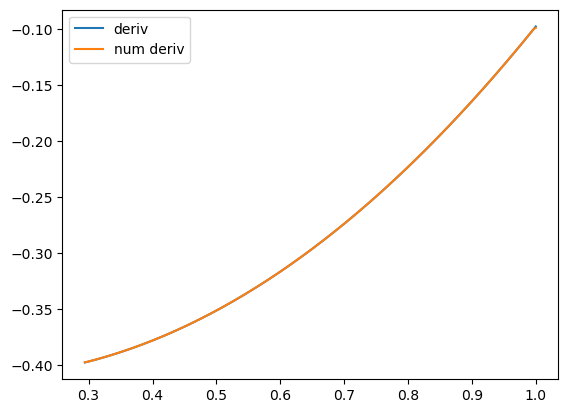

In [5]:
## Comparing analytical derivative and numerical derivative of chebyshev polynomia
anal_deriv=cheb_deriv(c,2*x-1)
num_deriv=np.gradient(cheb_acos(c,2*x-1),2*x-1)
plt.plot(a,anal_deriv,label="deriv")
# plt.plot(a,cheb1(c,2*x-1),label="cheb")
plt.plot(a,num_deriv,label="num deriv")
plt.legend()

np.max((anal_deriv-num_deriv)/num_deriv)

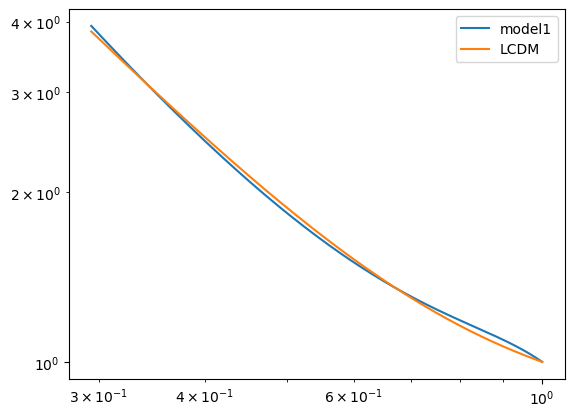

In [4]:
c0 = 0.944
c1 = -0.357
c2 = 0.047
c3 = 0.0052
a = np.linspace(0.294118,1.0,200)
n_cheb = 4
c=np.zeros(n_cheb)

for i in range(n_cheb) :
    c[i]=eval(f"c{i}")
da = (1-a[0])/a[0]
x = (a-a[0])/(a[-1]-a[0])
h0 = 0.735

model1 = da/(1+da*x)**2/cheb_acos(c,2*x-1)/h0
# model2 = da/(1+da*x)**2/cheb2(c,2*x-1)/h0
model1 = model1/model1[-1]
# model2 = model2/model2[-1]

omega_m = 0.3596
omega_l = 1-omega_m
hubble = 0.735 # 0.6766
a = np.linspace(0.294118,1.0,200)
expf = np.sqrt (omega_m/a**3 + omega_l)

plt.loglog(a,model1,label="model1")
# plt.loglog(a,model2,label="model2")
plt.loglog(a,expf,label="LCDM")
plt.legend();
# print("Max relative error:", np.max(np.abs((model1 - model2) / model2)))
# print("All close?", np.allclose(model1, model2, rtol=1e-12))

In [4]:
def plot_model(c0,c1,c2,c3,a) :
    n_cheb = 4
    c=np.zeros(n_cheb)
    for i in range(n_cheb) :
        c[i]=eval(f"c{i}")
    da = (1-a[0])/a[0]
    x = (a-a[0])/(a[-1]-a[0])
    model = da/(1+da*x)**2/cheb_recursive(c,2*x-1)/h0
    model = model/model[-1]

    omega_m = 0.3596
    omega_l = 1-omega_m
    hubble = 0.735 # 0.6766
    expf = np.sqrt (omega_m/a**3 + omega_l)
    
    plt.loglog(a,model,label="model")
    plt.loglog(a,expf,label="LCDM")
    plt.legend();

In [5]:
a = np.linspace(0.294118,1.0,200)
c0 = 0.944
c1 = -0.357
c2 = 0.047
c3 = 0.0052
# c0 = 1.2330133342758				
# c1 = 0.293462481244696
# c2 = -0.6124208395993557	
# c3 = -0.052467339134178115

plot_model(c0,c1,c2,c3,a)

NameError: name 'h0' is not defined